In [1]:
"""
full dataset

------------------------------------------------------------------------------------------------
|                                                                                              |
------------------------------------------------------------------------------------------------

regular splitting

------------------------------------------------------------------------------------------------
|                              70%                                  |    15%          |       15%         |
------------------------------------------------------------------------------------------------

Cross Validation

------------------------------------------------------------------------------------------------
|      1          |          2     |       3        |        4        |        5        |        6        |
------------------------------------------------------------------------------------------------
"""

'\nfull dataset\n\n------------------------------------------------------------------------------------------------\n|                                                                                              |\n------------------------------------------------------------------------------------------------\n\nregular splitting\n\n------------------------------------------------------------------------------------------------\n|                              70%                                  |    15%          |       15%         |\n------------------------------------------------------------------------------------------------\n\nCross Validation\n\n------------------------------------------------------------------------------------------------\n|      1          |          2     |       3        |        4        |        5        |        6        |\n------------------------------------------------------------------------------------------------\n'

In [2]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
                                    StratifiedKFold, 
                                    cross_validate,
                                    train_test_split
                                    )
from sklearn.metrics import (
                            confusion_matrix, 
                            f1_score,
                            accuracy_score,
                            precision_score,
                            recall_score
                            )
from imblearn.over_sampling import SMOTENC
warnings.filterwarnings('ignore')

### 1. Load the data

In [3]:
from pathlib import Path

project_root = Path.cwd()
for parent in [project_root, *project_root.parents]:
    if (parent / 'artifacts').exists():
        project_root = parent
        break

with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_train.npz') as data:
    X_train = data['X_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_train.npz') as data:
    Y_train = data['y_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_test.npz') as data:
    X_test = data['X_test']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_test.npz') as data:
    Y_test = data['y_test']

### 2. Configure k-Fold CV

In [4]:
cv = StratifiedKFold(
                    n_splits=6,
                    random_state=42,
                    shuffle=True
                    )

In [5]:
model_lr = LogisticRegression(
                            C=0.01,
                            max_iter=1000,
                            random_state=42
                            )

In [6]:
cv_results = cross_validate(
                            model_lr,
                            X_train,
                            Y_train,
                            cv=cv, scoring='precision',
                            return_train_score=False
                            )

In [7]:
cv_results

{'fit_time': array([0.01873636, 0.02137208, 0.01953077, 0.01540852, 0.01796055,
        0.01503205]),
 'score_time': array([0.00536823, 0.00301266, 0.00547314, 0.00328922, 0.00179362,
        0.02902126]),
 'test_score': array([0.92750533, 0.93543759, 0.93133047, 0.92008487, 0.93204578,
        0.92984968])}

In [8]:
score_arr = ['accuracy', 'precision', 'recall', 'f1']
for score in score_arr:
    cv_results = cross_validate(
                                model_lr,
                                X_train,
                                Y_train,
                                cv=cv, scoring=score,
                                return_train_score=False
                                )
    test_score = cv_results['test_score']
    test_score_avg = np.mean(test_score)

    print(f"{score} : {test_score_avg}")

accuracy : 0.9581797371854547
precision : 0.9293756192432138
recall : 0.9917501409431425
f1 : 0.9595441575054328


In [9]:
cv_results = cross_validate(
                            model_lr,
                            X_train, Y_train,
                            cv=cv, scoring='f1',
                            return_train_score=False
                            )
cv_results

{'fit_time': array([0.02409291, 0.02430558, 0.02734447, 0.02536249, 0.02627993,
        0.02096486]),
 'score_time': array([0.00440645, 0.00753093, 0.00767541, 0.00392437, 0.00474   ,
        0.00585961]),
 'test_score': array([0.95955882, 0.96307238, 0.96053117, 0.95416208, 0.9612689 ,
        0.95867159])}

In [10]:
# Load the original scaled dataset to perform threshold search on imbalanced data
from pathlib import Path
project_root = Path.cwd()
for parent in [project_root, *project_root.parents]:
    if (parent / 'artifacts').exists():
        project_root = parent
        break

df_orig = pd.read_csv(project_root / 'dataset' / 'processed' / 'credit_card_fraud_scaled.csv')
if 'transaction_id' in df_orig.columns:
    df_orig = df_orig.drop(columns=['transaction_id'])

X_orig = df_orig.drop(columns=['is_fraud'])
y_orig = df_orig['is_fraud']

# Split in exactly the same way to retrieve original training split
X_train_orig, _, y_train_orig, _ = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

# Identify categorical features for SMOTENC
CONTINUOUS_COLS = ['amount', 'transaction_hour', 'velocity_last_24h', 'cardholder_age']
categorical_cols = [col for col in X_train_orig.columns if col not in CONTINUOUS_COLS]
categorical_features = [X_train_orig.columns.get_loc(col) for col in categorical_cols]

# Perform Stratified K-Fold CV on the original training set to get OOF probabilities
oof_probs = np.zeros(len(X_train_orig))
for train_idx, val_idx in cv.split(X_train_orig, y_train_orig):
    X_tr_fold, y_tr_fold = X_train_orig.iloc[train_idx], y_train_orig.iloc[train_idx]
    X_val_fold, y_val_fold = X_train_orig.iloc[val_idx], y_train_orig.iloc[val_idx]
    
    # Balance training fold using SMOTENC
    smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
    X_tr_res, y_tr_res = smotenc.fit_resample(X_tr_fold, y_tr_fold)
    
    # Fit fold model
    fold_model = LogisticRegression(C=0.01, max_iter=1000, random_state=42)
    fold_model.fit(X_tr_res, y_tr_res)
    
    # Predict probabilities on the imbalanced validation fold
    oof_probs[val_idx] = fold_model.predict_proba(X_val_fold)[:, 1]

# Find threshold that maximizes F1-score on imbalanced OOF training predictions
best_threshold = 0.5
best_f1 = 0
for th in np.linspace(0.01, 0.99, 99):
    y_pred_th = (oof_probs >= th).astype(int)
    f1 = f1_score(y_train_orig, y_pred_th)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print(f"Optimal threshold found on imbalanced OOF validation folds: {best_threshold:.4f} (OOF F1: {best_f1:.4f})")

Optimal threshold found on imbalanced OOF validation folds: 0.8600 (OOF F1: 0.5344)


In [11]:
# Fit the final model on the entire SMOTE-balanced training set from artifacts
model_lr = LogisticRegression(
                            C=0.01,
                            max_iter=1000,
                            random_state=42
                            )
model_lr.fit(X_train, Y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [12]:
# Predict probabilities and apply the optimized threshold
Y_proba_train = model_lr.predict_proba(X_train)[:, 1]
Y_proba_test = model_lr.predict_proba(X_test)[:, 1]

Y_hat_train = (Y_proba_train >= best_threshold).astype(int)
Y_hat_test = (Y_proba_test >= best_threshold).astype(int)

In [13]:
accuracy = accuracy_score(Y_test, Y_hat_test)
precision = precision_score(Y_test, Y_hat_test)
recall = recall_score(Y_test, Y_hat_test)
f1_value = f1_score(Y_test, Y_hat_test)

In [14]:
print(f"accuracy : {accuracy}")
print(f"precision : {precision}")
print(f"recall : {recall}")
print(f"f1_score : {f1_value}")

accuracy : 0.988
precision : 0.5789473684210527
recall : 0.7333333333333333
f1_score : 0.6470588235294118


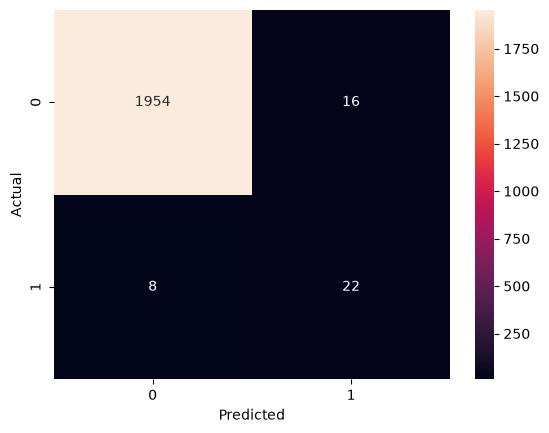

In [15]:
cm = confusion_matrix(Y_test, Y_hat_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()